# Vocabulary Level Prediction

## Model Selection

## 0. Enviorment Setting

Re-run the code cell below after you edit `utils.py` or `modeling_utils.py`: it uses `importlib.reload` (same idea as [EDA.ipynb](EDA.ipynb)) so the kernel picks up changes without restarting.

In [79]:
import importlib
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Load project modules first, then reload so edits to .py files apply without kernel restart.
import modeling_utils
import utils

importlib.reload(utils)
importlib.reload(modeling_utils)

from modeling_utils import (
    filter_by_rater_agreement,
    create_consensus_target,
    build_text_target_dataset,
    build_stratification_bins,
    build_experiments_from_grid,
    build_experiments_from_track_specs,
    build_experiment_registry,
    DEFAULT_TFIDF_VECTORIZER_KWARGS,
    run_all_experiments_cv,
    build_cv_leaderboard,
    style_cv_leaderboard,
    plot_cv_metric_bars,
    plot_cv_fold_boxplot,
    UniformRandomScoreRegressor,
)
from utils import (
    get_text_length_features_df,
    get_vocabulary_richness_df,
    get_essay_embeddings,
)
from sklearn.linear_model import ElasticNet, Lasso, Ridge
from sklearn.neural_network import MLPRegressor
from sklearn.svm import LinearSVR

try:
    from xgboost import XGBRegressor
except ImportError:
    XGBRegressor = None
try:
    from lightgbm import LGBMRegressor
except ImportError:
    LGBMRegressor = None

pd.set_option("display.max_colwidth", None)

## 1. Load data

In [15]:
df_train = pd.read_csv("Data/train.csv")
print(f"Train: {len(df_train)} rows")

Train: 7112 rows


## 2. Preprocessing

In [16]:
rows_before = len(df_train)
df_train = filter_by_rater_agreement(df_train)
print(f"Removed {rows_before - len(df_train)} rows (|V1-V2| >= 2), kept {len(df_train)}")

Removed 308 rows (|V1-V2| >= 2), kept 6804


In [17]:
df_train = create_consensus_target(df_train)
df_train["target_vocab"].value_counts().sort_index()

target_vocab
0      11
1       1
2    1270
3    2343
4    3114
5      65
Name: count, dtype: int64

In [31]:
df_train_text_target = build_text_target_dataset(df_train)
# df_train_text_target.head()

## 3. Precomputed label-free features

We precompute features that depend only on essay text (or on a frozen pretrained encoder) and never use `target_vocab`. That avoids label leakage.

Transforms that **learn** from the training corpus must still be fit **inside each CV fold** (for example TF-IDF, `StandardScaler`, PCA/SVD).

Subsections below build two such matrices for this notebook; CV will index rows and fit scalers/models per fold only.

### 3.1 Handcrafted features

Four columns from existing EDA helpers: `unique_words`, `sentence_count`, `char_count`, `word_count` — each row is a deterministic function of `Text_cleaned` only.

In [19]:
length_features_df = get_text_length_features_df(df_train_text_target, text_column="Text_cleaned")
richness_features_df = get_vocabulary_richness_df(df_train_text_target, text_column="Text_cleaned")

X_handcrafted_precomputed = pd.DataFrame(
    {
        "unique_words": richness_features_df["unique_words"],
        "sentence_count": length_features_df["sentence_count"],
        "char_count": length_features_df["char_count"],
        "word_count": length_features_df["word_count"],
    },
    index=df_train_text_target.index,
)
X_handcrafted_precomputed.head()

,unique_words,sentence_count,char_count,word_count
0,115,7,1281,254
1,162,15,2232,448
2,100,6,843,172
3,105,15,1777,351
4,108,7,1025,181


### 3.2 Sentence embeddings

Frozen sentence-transformer encoding via `get_essay_embeddings` with `use_fast_model=True` (same as EDA: smaller MiniLM-L3 model, much faster on CPU). Inference only; weights not updated on this dataset. Same row order as `df_train_text_target`.

**About the `BertModel LOAD REPORT` line (`embeddings.position_ids | UNEXPECTED`):** newer `sentence-transformers` prints a **weight-key checklist** when the saved checkpoint contains keys the loaded architecture does not use (here: redundant `position_ids` buffers; modern BERT builds positions on the fly). The model still loads with the intended weights — this is **not** a failed load and **not** something we paper over with warning filters. If it is distracting, upgrade `sentence-transformers` / `transformers` when a release tightens this report; behaviour is unchanged.

In [21]:
X_embeddings_precomputed = get_essay_embeddings(
    df=df_train_text_target,
    text_column="Text_cleaned",
    use_fast_model=True,
    batch_size=256,
)
X_embeddings_precomputed.shape

Loading weights: 100%|██████████| 55/55 [00:00<00:00, 2351.88it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-MiniLM-L3-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 492/492 [06:53<00:00,  1.19it/s]


(6804, 384)

## 4. Model Selection

One stratified 5-fold CV workflow (multiple cells, one logical evaluation pass). **`run_all_experiments_cv`** loops the full **experiment registry**, routes each row by `feature_source`, and runs **`run_stratified_cv`** per experiment.

**Registry (per plan):** **starting-point** hyperparameters (not grid search): milder **Ridge** `alpha` than sklearn’s default for high-dim text; **Lasso/ElasticNet** `alpha` + `max_iter`/`tol` suited to sparse TF-IDF and convergence; **LinearSVR** `C`/`max_iter`/`dual`; **MLP** after SVD with early stopping; **XGB/LGBM** use **library defaults** for capacity (depth, trees, leaves, learning rate) — only `random_state`, `n_jobs`, and **`tree_method="hist"`** for XGB (efficient on wide sparse data without shallow trees). **`verbosity=-1`** for LGBM silences logs. **XGB/LGB “feature names” warnings** are addressed in **`modeling_utils._materialize_fold_features`** (DataFrame→numpy).
- **Random baseline:** `random_baseline_U01` — uniform random score in `[0, 5]` (ignores features). Expect QWK ≈ 0 and worse RMSE/MAE than real models.
- **Baseline:** `StandardScaler` + `Ridge` on the four handcrafted columns only (`handcrafted_Ridge`).
- **TF-IDF track:** `Pipeline([TfidfVectorizer, model])` for Ridge, Lasso, ElasticNet, LinearSVR, XGBoost, LightGBM, MLP (**RandomForest dropped** — too slow on 20K sparse features with little gain). **MLP** uses **`TfidfVectorizer` → `TruncatedSVD` → `MLPRegressor`**.
- **Embedding track:** same model set on 384-d embeddings; **StandardScaler + model** for linear / MLP; **no scaler** for XGB / LGBM.

**CV config:** `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)`.

**Metrics (per fold, then averaged):** **QWK** = quadratic weighted kappa on **rounded/clipped** predictions in 0–5 (fixed label set `{0,…,5}` for sklearn). **RMSE** and **MAE** compare **continuous** predictions to integer `y` (regression error). Progress prints show **mean QWK, RMSE, MAE** across folds for each experiment.

**Leakage:** TF-IDF / scalers / SVD fit only on training-fold rows; precomputed features are indexed by fold; `sample_weight` from fold `y_train` only.

**Stratification:** labels 0 and 1 merged into one bin for fold assignment only (rare classes).

In [80]:
# --- Experiment registry (Section 4) ---
# Reasonable starting points (not Optuna): regularization for text/high-dim, convergence budgets,
# and moderate boosting. `random_state` for reproducibility. XGB/LGB feature-name warnings:
# fixed in modeling_utils._materialize_fold_features (pass numpy), not via these kwargs.
CV_RANDOM_STATE = 42

HANDCRAFTED_BASELINE_ESTIMATORS = [
    # alpha=0.1: sklearn default 1.0 is stiff for four raw count features.
    # solver='lsqr': works with sparse TF-IDF + intercept; stable for small dense handcrafted matrices.
    ("Ridge", Ridge(alpha=0.1, solver="lsqr", random_state=CV_RANDOM_STATE)),
]

FULL_MODEL_ESTIMATORS = [
    # alpha=0.1: milder L2 than default 1.0 for high-dim text.
    # solver='lsqr': sklearn forbids solver='svd' on sparse TF-IDF (intercept); lsqr supports sparse+dense.
    ("Ridge", Ridge(alpha=0.1, solver="lsqr", random_state=CV_RANDOM_STATE)),
    (
        "Lasso",
        Lasso(
            alpha=0.001,
            max_iter=5000,
            tol=1e-3,
            random_state=CV_RANDOM_STATE,
        ),
    ),
    (
        "ElasticNet",
        ElasticNet(
            alpha=0.001,
            l1_ratio=0.5,
            max_iter=50000,  # coordinate descent did not converge at 5000 on 384-d embeddings; still <1 s
            tol=1e-3,
            random_state=CV_RANDOM_STATE,
        ),
    ),
    (
        "LinearSVR",
        # max_iter=50000: liblinear did not converge at 8000 on 384-d embeddings; trivial runtime on small d
        LinearSVR(max_iter=50000, C=0.5, dual=True),
    ),
    (
        "MLP",
        MLPRegressor(
            hidden_layer_sizes=(256,),
            max_iter=500,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=15,
            random_state=CV_RANDOM_STATE,
        ),
    ),
    # TF-IDF path: TfidfVectorizer -> TruncatedSVD -> MLP; early_stopping caps wall time.
]
if XGBRegressor is not None:
    FULL_MODEL_ESTIMATORS.append(
        (
            "XGB",
            XGBRegressor(
                # Library defaults for n_estimators, max_depth, learning_rate, subsample, etc.
                # Only set: reproducibility, parallelism, and hist (fast on high-dim sparse; not shallower trees).
                tree_method="hist",
                random_state=CV_RANDOM_STATE,
                n_jobs=-1,
            ),
        )
    )
if LGBMRegressor is not None:
    FULL_MODEL_ESTIMATORS.append(
        (
            "LGBM",
            LGBMRegressor(
                random_state=CV_RANDOM_STATE,
                n_jobs=-1,
                verbosity=-1,
            ),
        )
    )

TRACK_SPECS = [
    {
        "feature_source": "random_uniform",
        "name_prefix": "random_baseline",
        "named_estimators": [
            (
                "U01",
                UniformRandomScoreRegressor(
                    random_state=CV_RANDOM_STATE,
                    min_score=0.0,
                    max_score=5.0,
                ),
            ),
        ],
    },
    {
        "feature_source": "handcrafted",
        "name_prefix": "handcrafted",
        "named_estimators": HANDCRAFTED_BASELINE_ESTIMATORS,
    },
    {
        "feature_source": "tfidf",
        "name_prefix": "tfidf",
        "named_estimators": FULL_MODEL_ESTIMATORS,
    },
    {
        "feature_source": "embeddings",
        "name_prefix": "emb",
        "named_estimators": FULL_MODEL_ESTIMATORS,
    },
]

TFIDF_KWARGS = dict(DEFAULT_TFIDF_VECTORIZER_KWARGS)

# build_experiment_registry == build_experiments_from_track_specs (plan naming).
experiment_registry = build_experiment_registry(
    track_specs=TRACK_SPECS,
    tfidf_vectorizer_kwargs=TFIDF_KWARGS,
    svd_n_components=300,
    tfidf_mlp_short_name="MLP",
)
# Show every experiment name 
len(experiment_registry), [exp["name"] for exp in experiment_registry]

(16,
 ['random_baseline_U01',
  'handcrafted_Ridge',
  'tfidf_Ridge',
  'tfidf_Lasso',
  'tfidf_ElasticNet',
  'tfidf_LinearSVR',
  'tfidf_MLP',
  'tfidf_XGB',
  'tfidf_LGBM',
  'emb_Ridge',
  'emb_Lasso',
  'emb_ElasticNet',
  'emb_LinearSVR',
  'emb_MLP',
  'emb_XGB',
  'emb_LGBM'])

In [81]:
# Targets and stratification bins (bins used only for fold assignment).
y = df_train_text_target["target_vocab"].values
stratification_bins = build_stratification_bins(y, merge_below=2)

# Row-aligned inputs per feature_source. "tfidf" must be raw text — vectorizer fits inside each fold.
_handcrafted_xy = X_handcrafted_precomputed.reset_index(drop=True)
feature_data_by_source = {
    "random_uniform": _handcrafted_xy,
    "handcrafted": _handcrafted_xy,
    "tfidf": df_train_text_target["Text_cleaned"].reset_index(drop=True),
    "embeddings": np.asarray(X_embeddings_precomputed),
}

In [82]:
all_fold_results = run_all_experiments_cv(
    experiments=experiment_registry,
    target_values=y,
    feature_data_by_source=feature_data_by_source,
    stratification_bins=stratification_bins,
    n_splits=5,
    random_state=42,
    use_sample_weights=True,
)
all_fold_results

  Running: random_baseline_U01 ... mean QWK=0.0095, RMSE=1.8378, MAE=1.5096
  Running: handcrafted_Ridge ... mean QWK=0.3451, RMSE=1.0546, MAE=0.8607
  Running: tfidf_Ridge ... mean QWK=0.4661, RMSE=0.7182, MAE=0.5755
  Running: tfidf_Lasso ... mean QWK=0.4137, RMSE=0.7492, MAE=0.6011
  Running: tfidf_ElasticNet ... mean QWK=0.4130, RMSE=0.6864, MAE=0.5588
  Running: tfidf_LinearSVR ... mean QWK=0.4990, RMSE=0.6903, MAE=0.5562
  Running: tfidf_MLP ... mean QWK=0.5113, RMSE=0.6793, MAE=0.5438
  Running: tfidf_XGB ... mean QWK=0.4229, RMSE=0.7226, MAE=0.5844
  Running: tfidf_LGBM ... mean QWK=0.4300, RMSE=0.6895, MAE=0.5622
  Running: emb_Ridge ... mean QWK=0.4238, RMSE=0.7998, MAE=0.6339
  Running: emb_Lasso ... mean QWK=0.4239, RMSE=0.7874, MAE=0.6249
  Running: emb_ElasticNet ... mean QWK=0.4234, RMSE=0.7888, MAE=0.6259
  Running: emb_LinearSVR ... 

c:\Users\gilad\CursorProjects\Vocabulary Level Prediction\.venv\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


mean QWK=0.4094, RMSE=0.8899, MAE=0.7008
  Running: emb_MLP ... mean QWK=0.3936, RMSE=0.7772, MAE=0.6258
  Running: emb_XGB ... mean QWK=0.2888, RMSE=0.7726, MAE=0.6277
  Running: emb_LGBM ... mean QWK=0.2987, RMSE=0.7309, MAE=0.6063


,experiment,fold,qwk,rmse,mae
0,random_baseline_U01,1,0.005546,1.843051,1.519984
1,random_baseline_U01,2,0.010323,1.834963,1.503791
2,random_baseline_U01,3,0.002478,1.847542,1.508232
3,random_baseline_U01,4,-0.021297,1.863664,1.539941
4,random_baseline_U01,5,0.050642,1.799537,1.476224
...,...,...,...,...,...
75,emb_LGBM,1,0.311245,0.723088,0.602613
76,emb_LGBM,2,0.312432,0.711940,0.593583
77,emb_LGBM,3,0.292369,0.729576,0.600070
78,emb_LGBM,4,0.285873,0.748228,0.618713


In [83]:
# Aggregate fold metrics: mean/std per experiment, sort by QWK then MAE (see modeling_utils).
cv_leaderboard = build_cv_leaderboard(all_fold_results)
style_cv_leaderboard(cv_leaderboard)

,experiment,qwk_mean,qwk_std,rmse_mean,rmse_std,mae_mean,mae_std
0,tfidf_MLP,0.5113,0.0076,0.6793,0.0195,0.5438,0.0184
1,tfidf_LinearSVR,0.4990,0.0118,0.6903,0.0203,0.5562,0.0159
2,tfidf_Ridge,0.4661,0.0101,0.7182,0.0111,0.5755,0.0088
3,tfidf_LGBM,0.4300,0.0107,0.6895,0.0085,0.5622,0.0051
4,emb_Lasso,0.4239,0.0165,0.7874,0.0118,0.6249,0.0093
5,emb_Ridge,0.4238,0.0166,0.7998,0.0123,0.6339,0.0097
6,emb_ElasticNet,0.4234,0.0174,0.7888,0.0128,0.6259,0.0100
7,tfidf_XGB,0.4229,0.0228,0.7226,0.0063,0.5844,0.0066
8,tfidf_Lasso,0.4137,0.0035,0.7492,0.0226,0.6011,0.0184
9,tfidf_ElasticNet,0.4130,0.0093,0.6864,0.0152,0.5588,0.0117


### 4.1 CV metric plots

Bar charts show **mean ± std** of each metric across folds (sorted so better values read left-to-right). The boxplot shows the **distribution of fold-level QWK** per experiment — useful for stability, not just average performance.

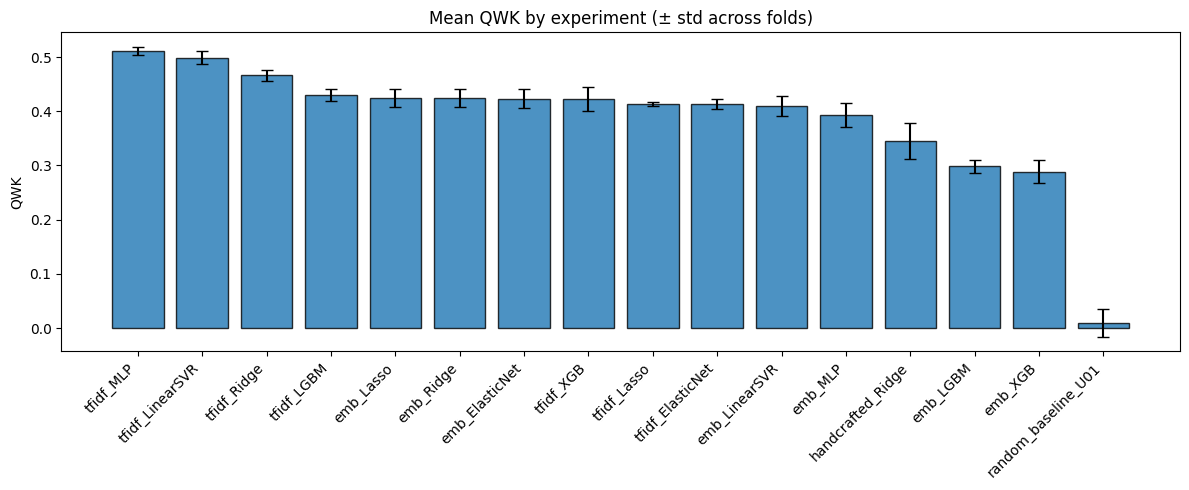

In [84]:
fig_qwk = plot_cv_metric_bars(
    cv_leaderboard,
    metric_mean_col="qwk_mean",
    metric_std_col="qwk_std",
    title="Mean QWK by experiment (± std across folds)",
    ylabel="QWK",
    higher_is_better=True,
)
plt.show()

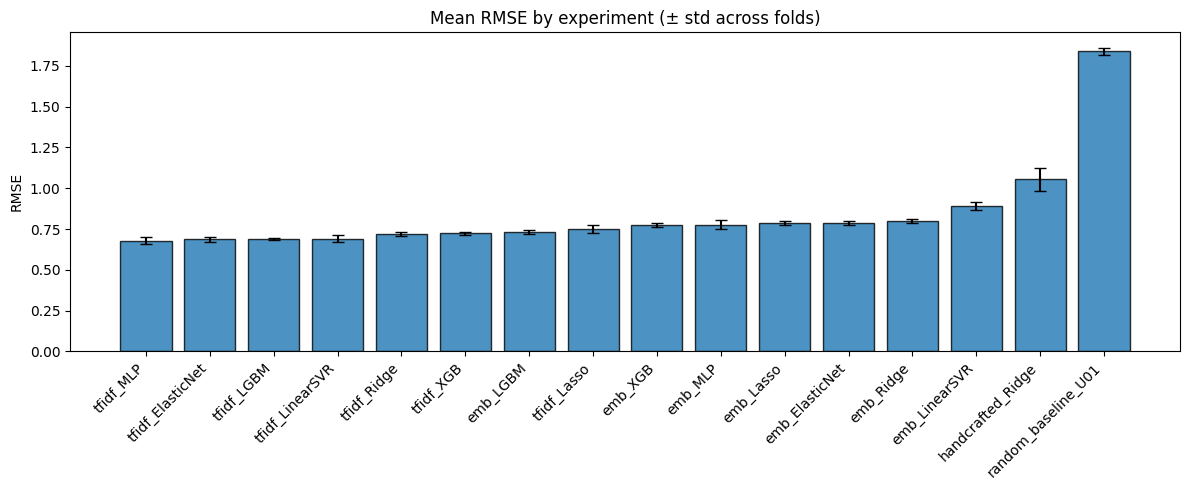

In [85]:
fig_rmse = plot_cv_metric_bars(
    cv_leaderboard,
    metric_mean_col="rmse_mean",
    metric_std_col="rmse_std",
    title="Mean RMSE by experiment (± std across folds)",
    ylabel="RMSE",
    higher_is_better=False,
)
plt.show()

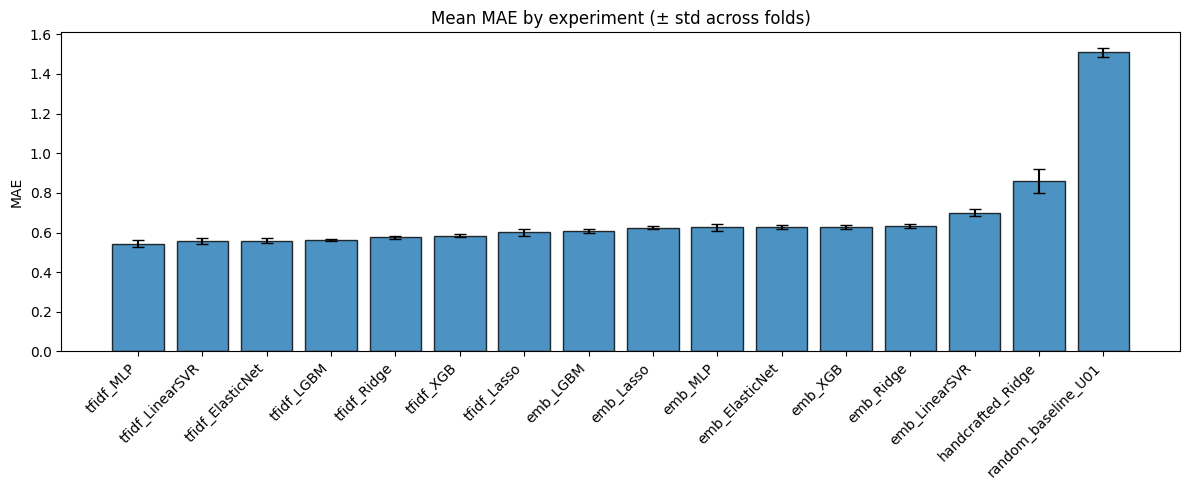

In [86]:
fig_mae = plot_cv_metric_bars(
    cv_leaderboard,
    metric_mean_col="mae_mean",
    metric_std_col="mae_std",
    title="Mean MAE by experiment (± std across folds)",
    ylabel="MAE",
    higher_is_better=False,
)
plt.show()

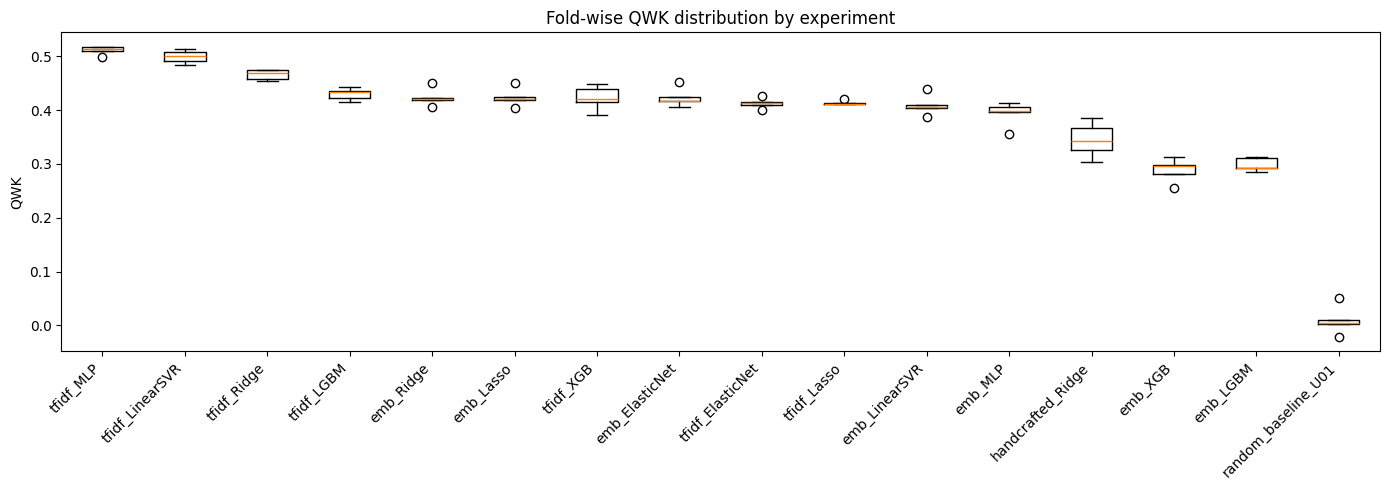

In [87]:
fig_box_qwk = plot_cv_fold_boxplot(all_fold_results, metric="qwk")
plt.show()

### 4.2 Winner selection

**Classical winner (CV):** first row of `cv_leaderboard` — highest mean QWK, tie-broken by lower mean MAE. Use this name in **Section 5** (hyperparameter tuning on that family only). Rationale: QWK matches the ordinal scoring task; MAE breaks ties on continuous error.

In [88]:
# Locked for Section 5+ (tuning / final evaluation orchestration).
CLASSICAL_CV_WINNER_EXPERIMENT = cv_leaderboard.iloc[0]["experiment"]
CLASSICAL_CV_WINNER_QWK_MEAN = float(cv_leaderboard.iloc[0]["qwk_mean"])
CLASSICAL_CV_WINNER_MAE_MEAN = float(cv_leaderboard.iloc[0]["mae_mean"])
CLASSICAL_CV_WINNER_EXPERIMENT, CLASSICAL_CV_WINNER_QWK_MEAN, CLASSICAL_CV_WINNER_MAE_MEAN

('tfidf_MLP', 0.5112696759044011, 0.5438126862677615)